# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
users_nuls= users.isnull().sum()
users_nul_prom = users.isnull().sum()/len(users) * 100
print( "Cantidad de valores nulos:",users_nuls)
print("Proporción de valores nulos:",users_nul_prom)

Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos: user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage
usge_nul= usage.isnull().sum()
usge_nul_pro= (usage.isnull().sum()/len(usage))*100
print ("cantidad de valores nulos:", usge_nul)
print ("proporcion de valores nulos:", usge_nul_pro)

cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
proporcion de valores nulos: id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- 
  **users**
    - city 469 nulos = 11.7%
    - churn_date 3534 nulos = 88.3%
  **usage**

    - date_duration 22076 nulos = 55.1%
    - length 17896 nulos = 44.7%

- Indica qué harías: ¿imputar, eliminar, ignorar?
1. Ignoraremos churn_date, ya que la proporción de datos nulos es muy alta, aunque explicable. Esto indica que la compañía conserva al 88.3% de sus clientes.

2. Imputaremos city. Debemos investigar por qué el 11.7% de los clientes no tiene registrada una ciudad.

3. Ignoraremos date_duration y length. La cantidad de valores vacíos en ambos casos es explicable: un mensaje no tiene duración y una llamada no tiene tamaño de archivo. Por lo tanto, las celdas vacías en ambas columnas se justifican por sí solas al leer el dataset.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna user_id presenta un comportamiento normal; al ser un identificador, carece de relevancia estadística.

- La columna age contiene un valor imposible (-999), probablemente un sentinel para indicar ausencia de datos.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas id y user_id son de identificación; user_id aparece como llave en el dataset de users.

- Las columnas duration y length son descriptivas y pueden emplearse para segmentar usuarios según la cantidad de mensajes, llamadas o la duración.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nColumna: {col}")
    print(users[col].value_counts(dropna=False))  # cuenta valores incluyendo nulos
    print("Valores únicos:", users[col].unique())
    print("-" * 40)


Columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Valores únicos: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
----------------------------------------

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64
Valores únicos: ['Basico' 'Premium']
----------------------------------------


- La columna city contiene numerosos valores erróneos. Además de las celdas vacías, los valores '?' y 'nan' no corresponden a ciudades válidas y deben ser imputados.
- La columna plan resulta especialmente útil para el análisis, ya que no contiene errores y se limita a dos categorías claramente definidas, lo que le otorga un elevado valor estadístico.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` es normal y tiene valor para el analicis.


---
✍️ **Comentario**: El dataset requiere ajustes para garantizar información clara y confiable.

- La columna city presenta el mayor número de inconsistencias, con 469 registros vacíos y 96 valores '?'. Estos deben eliminarse, pues aunque la columna es relevante, la proporción de errores es baja y su depuración no comprometerá los resultados finales.

- La columna age contiene valores sentinel (-999), cuya naturaleza debe analizarse cuidadosamente. Es necesario determinar si corresponde aplicar un proceso de winsorización o eliminación, dado que su tratamiento sí podría influir en la validez del análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En la columna reg_date se observan años imposibles: un total de 40 celdas contienen valores incorrectos.

In [19]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, unicamente tenmos registros del año que buscamos analizar, esta columna esta bien.

✍️ **Comentario**: La columna reg_date en el dataset de users presenta valores no válidos, además de registros vacíos. Dado que su depuración no compromete la calidad del análisis, se recomienda eliminar estos errores para garantizar resultados más claros y confiables.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
#
 #Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date']= pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts()


2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

In [23]:
#Corregir el formato de la columna usd_monthly_pay
plans["usd_monthly_pay"]= plans["usd_monthly_pay"].astype(float)

#Muestra los resultaods
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      float64
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(4), int64(3), object(1)
memory usage: 256.0+ bytes


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration_null"]= usage["duration"].isna()
duration_type = usage.groupby("type")["duration_null"].sum()
print("Nulos en duration por type:\n", duration_type)

Nulos en duration por type:
 type
call        0
text    22076
Name: duration_null, dtype: int64


In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage["length_nuls"] = usage["length"].isna()
length_type = usage.groupby("type")["length_nuls"].sum()
print("nulos en length por type:\n",length_type)

nulos en length por type:
 type
call    17896
text        0
Name: length_nuls, dtype: int64


No hay duda: las columnas duration y length presentan valores vacíos que se comportan como MAR (Missing At Random), dependiendo por completo de la columna type. Los textos no tienen duración y las llamadas no tienen tamaño de archivo; por lo tanto, ignoraremos estas columnas y continuaremos con el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',     # total de mensajes
    'is_call': 'sum',     # total de llamadas
    'duration': 'sum',    # duración total
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    "is_call": "cant_llamadas",
    "is_text": "cant_mensajes",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on='user_id', how='left')


user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:

# Resumen estadístico de las columnas numéricas
numerics_cols = ["cant_mensajes", "cant_llamadas","cant_minutos_llamada"]

for col in numerics_cols:
    print("resumen de ",col,":")
    print( user_profile[col].describe())                                    #resumen estadistico por columna
    print()


resumen de  cant_mensajes :
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

resumen de  cant_llamadas :
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

resumen de  cant_minutos_llamada :
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64



In [30]:
# Distribución porcentual del tipo de plan
plan_dist = user_profile["plan"].value_counts(normalize=True) * 100    #distribucion por plan
print(plan_dist)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

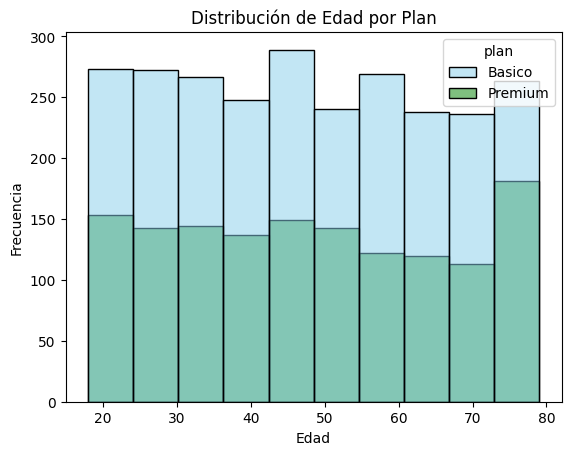

In [31]:
# Histograma para visualizar la edad (age)
sn.histplot(data=user_profile, x="age", hue="plan", palette=["skyblue","green"], bins=10)
plt.title("Distribución de Edad por Plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
La distribución es aproximadamente normal, con un ligero sesgo hacia la izquierda. Se observa una mayor concentración de clientes entre 70 y 80 años, aunque también existen cantidades considerables de clientes en los rangos de 40, 50 y 60 años, presentes en ambos tipos de plan.

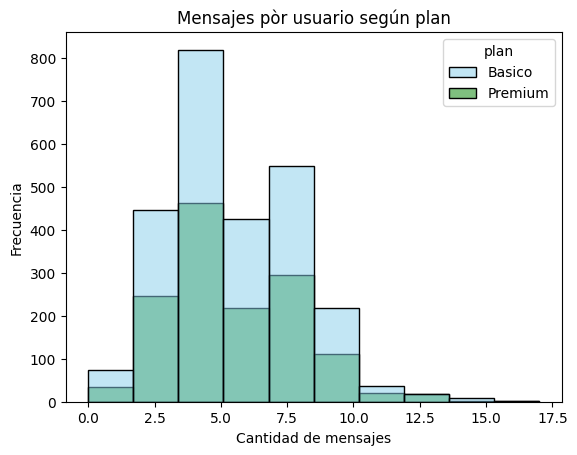

In [32]:
# Histograma para visualizar la cant_mensajes

sn.histplot(data=user_profile, x="cant_mensajes",hue="plan",palette=["skyblue","green"],bins=10)
plt.title("Mensajes pòr usuario según plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
Se observa un sesgo hacia la derecha: muy pocos clientes envían más de 10 mensajes, mientras que la mayoría se concentra en el rango central, entre 2 y 7 mensajes.

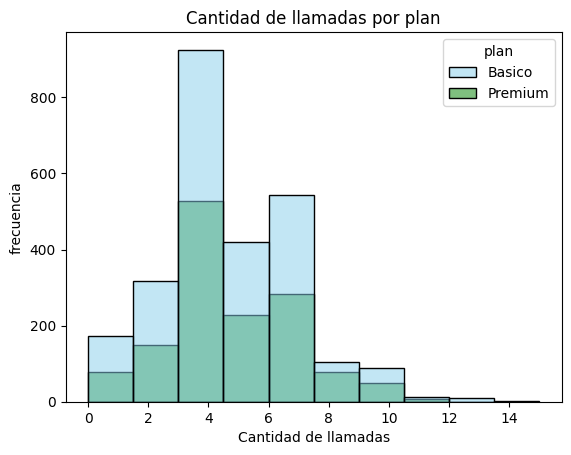

In [33]:
# Histograma para visualizar la cant_llamadas

sn.histplot(data=user_profile, x="cant_llamadas",hue="plan",palette=["skyblue","green"],bins=10)
plt.title("Cantidad de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("frecuencia")
plt.show()

💡Insights: 
La distribución presenta un claro sesgo hacia la derecha: pocos clientes realizan más de 10 llamadas, concentrándose la actividad de ambos planes principalmente entre 4 y 8 llamadas.

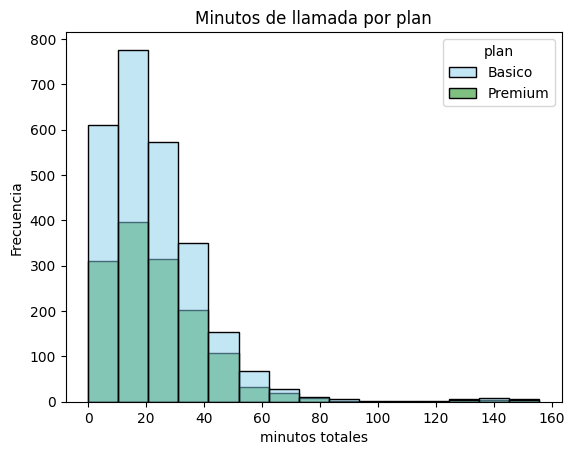

In [34]:
# Histograma para visualizar la cant_minutos_llamada

sn.histplot(data=user_profile, x="cant_minutos_llamada",hue="plan",palette=["skyblue","green"],bins=15)
plt.title("Minutos de llamada por plan")
plt.xlabel("minutos totales")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
La distribución presenta un sesgo hacia la derecha, con una cola muy larga. Un número reducido de clientes acumula hasta 140 minutos en llamadas, mientras que la mayoría se concentra entre 0 y 20 minutos, lo que genera la extensión de la cola.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

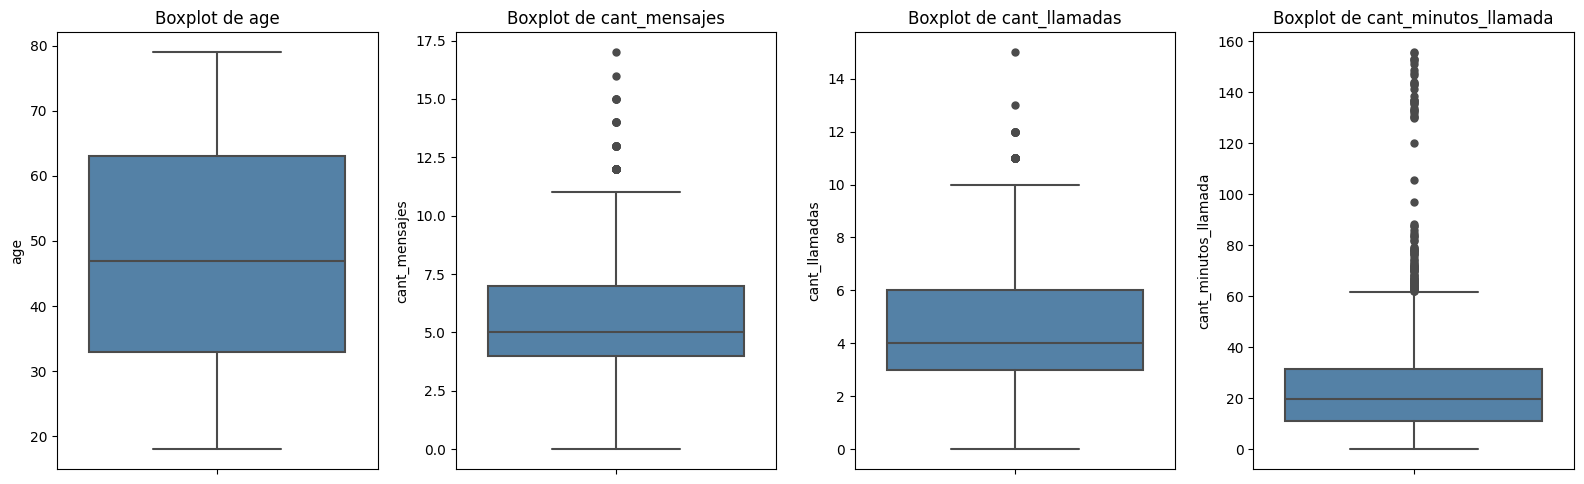

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
sn.set_theme(style="whitegrid")


# Loop para graficar cada boxplot
for i, col in enumerate(columnas_numericas):
    sn.boxplot(
        y=user_profile[col],
        ax=axes[i],
        color="steelblue",
        flierprops=dict(marker='o', color='red', markersize=5)
    )
    axes[i].set_title(f"Boxplot de {col}")

# Ajustar layout
plt.tight_layout()
plt.show()

💡Insights: 
- age: no presenta outliers ni edades fuera de rango.

- cant_mensajes: presenta algunos outliers que podrían considerarse parte de un comportamiento normal.

- cant_llamadas: muestra outliers en menor medida que cant_mensajes, pero siguen siendo consistentes con un patrón normal.

- La columna cant_minutos_llamada presenta la mayor cantidad de outliers. La mayoría de los clientes registran entre 20 y 60 minutos en llamadas, mientras que solo unos pocos superan los 100 minutos.

In [36]:
# Calcular límites con el método IQR
columnas_limites = ["cant_llamadas","cant_mensajes","cant_minutos_llamada","age"]

for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR= Q3-Q1

    limite_inferior = Q1-1.5*IQR
    limite_superior = Q3+1.5*IQR
       
    print(f" Columna: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")


 Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5
 Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5
 Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575
 Columna: age
Q1: 33.0
Q3: 63.0
IQR: 30.0
Límite inferior: -12.0
Límite superior: 108.0


In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_llamadas,cant_mensajes,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,4000.000000
mean,4.478120,5.524381,23.317054,48.122250
std,2.144238,2.358416,18.168095,17.690408
min,0.000000,0.000000,0.000000,18.000000
25%,3.000000,4.000000,11.120000,33.000000
50%,4.000000,5.000000,19.780000,47.000000
75%,6.000000,7.000000,31.415000,63.000000
max,15.000000,17.000000,155.690000,79.000000


💡Insights: 
- cant_mensajes: no se deben mantener los outliers, ya que son pocos y, aunque se alejan ligeramente del límite superior, generan confusión en el gráfico de caja.

- cant_llamadas: tampoco se deben mantener los outliers, pues aunque no están muy lejos del límite superior, su baja frecuencia no representa la realidad del mercado.

- cant_minutos_llamada: se deben mantener, ya que constituyen una cantidad considerable de outliers. Aunque se alejan mucho del límite superior, es plausible que un cliente registre hasta 2 horas en llamadas. Sin embargo, se recomienda aplicar winsorización para mantener el control estadístico.

In [38]:
#funcion para eliminar otliers

def eliminar_outliers(df, columnas):
    df_filtrado = df.copy()
    
    for col in columnas:
        Q1 = df_filtrado[col].quantile(0.25)
        Q3 = df_filtrado[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_sup = Q3 + 1.5 * IQR
        
        df_filtrado = df_filtrado[df_filtrado[col] <= limite_sup]
    
    return df_filtrado

In [39]:
#Eliminar otliers de cant_llamadas y cant_mensajes:

user_profile_clean = eliminar_outliers(
    user_profile, 
    ['cant_mensajes', 'cant_llamadas']
)

In [40]:
# Winsorizar cant_minutos_llamada
Q1_min = user_profile_clean['cant_minutos_llamada'].quantile(0.25)
Q3_min = user_profile_clean['cant_minutos_llamada'].quantile(0.75)
IQR_min = Q3_min - Q1_min
limite_sup_min = Q3_min + 1.5 * IQR_min

# Winsorizar (reemplazar valores extremos por el límite)
user_profile_clean['cant_minutos_llamada_win'] = user_profile_clean['cant_minutos_llamada'].clip(upper=limite_sup_min)

In [41]:
# Comparar valores máximos antes y después del tratamiento
print("=== COMPARACIÓN DE VALORES MÁXIMOS ===\n")

# Para las columnas donde eliminaste outliers
print("ELIMINACIÓN DE OUTLIERS:")
print(f"cant_mensajes - Antes: {user_profile['cant_mensajes'].max():.2f}")
print(f"cant_mensajes - Después: {user_profile_clean['cant_mensajes'].max():.2f}")
print()
print(f"cant_llamadas - Antes: {user_profile['cant_llamadas'].max():.2f}")
print(f"cant_llamadas - Después: {user_profile_clean['cant_llamadas'].max():.2f}")
print()

# Para la columna winsorizada
print("WINSORIZACIÓN:")
print(f"cant_minutos_llamada - Antes: {user_profile['cant_minutos_llamada'].max():.2f}")
print(f"cant_minutos_llamada - Después: {user_profile_clean['cant_minutos_llamada_win'].max():.2f}")

=== COMPARACIÓN DE VALORES MÁXIMOS ===

ELIMINACIÓN DE OUTLIERS:
cant_mensajes - Antes: 17.00
cant_mensajes - Después: 11.00

cant_llamadas - Antes: 15.00
cant_llamadas - Después: 10.00

WINSORIZACIÓN:
cant_minutos_llamada - Antes: 155.69
cant_minutos_llamada - Después: 61.23


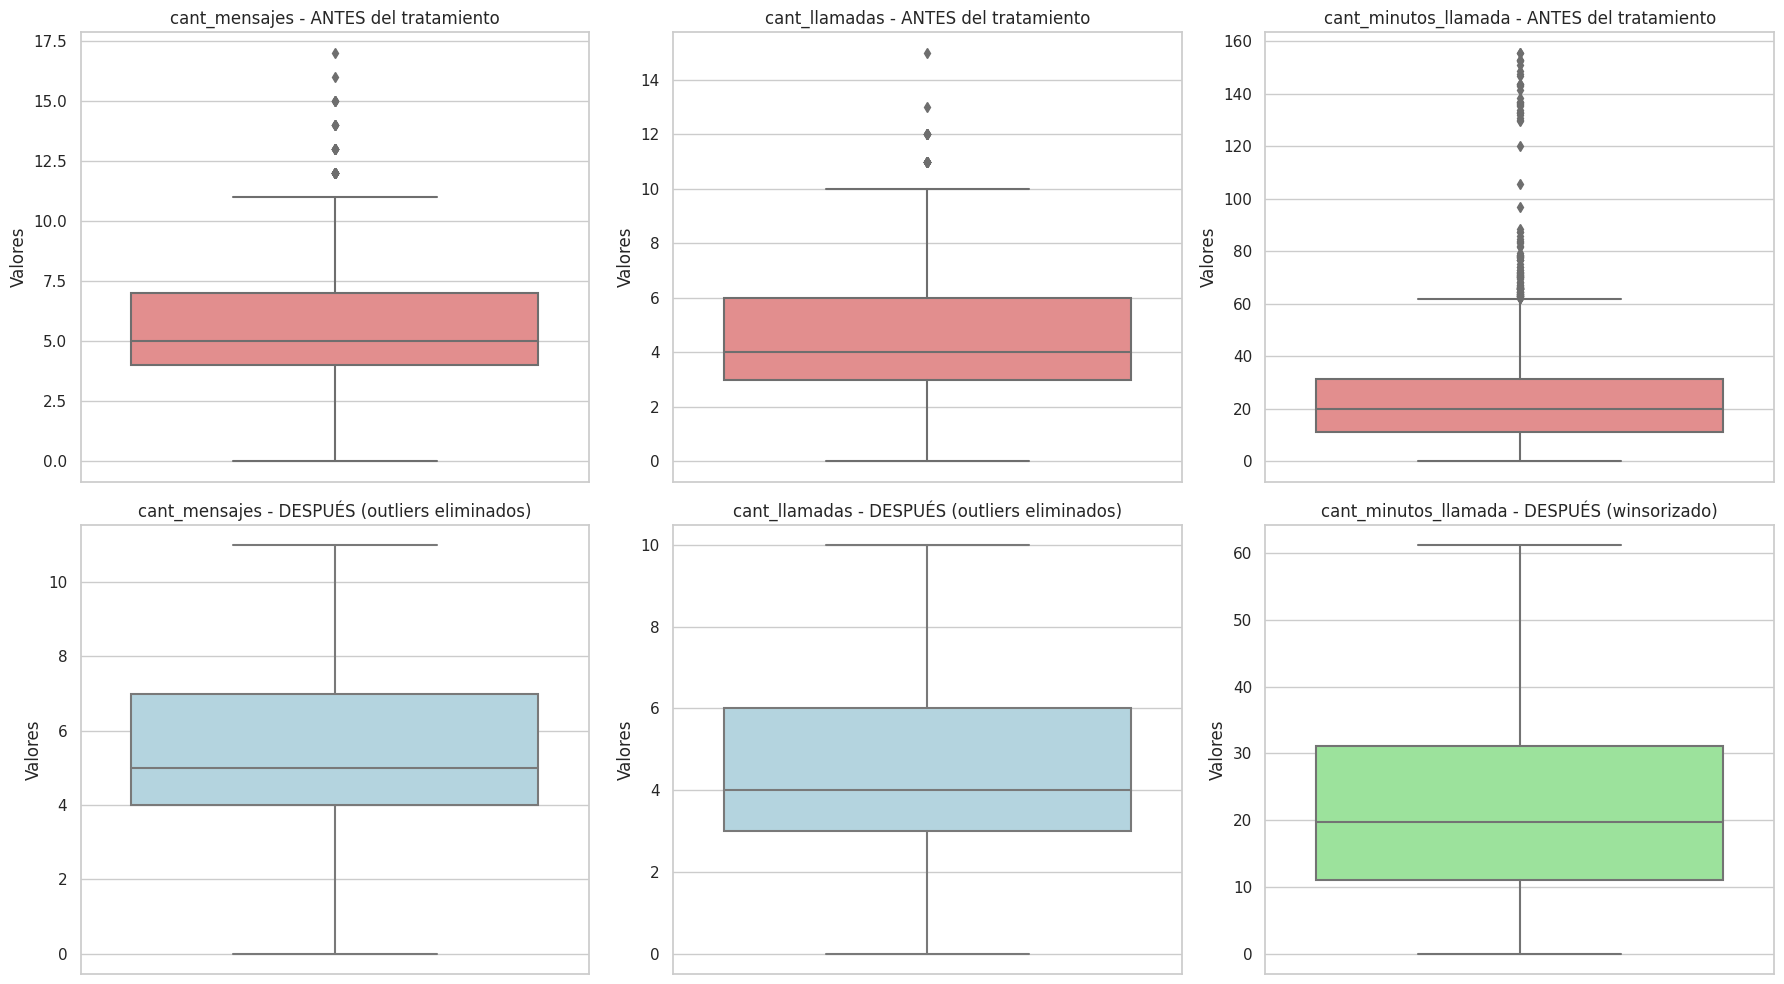

In [42]:
 #Crear gráficos de comparación antes/después
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Fila 1: Datos originales
columnas_originales = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for i, col in enumerate(columnas_originales):
    sn.boxplot(y=user_profile[col], ax=axes[0, i], color="lightcoral")
    axes[0, i].set_title(f"{col} - ANTES del tratamiento")
    axes[0, i].set_ylabel("Valores")

# Fila 2: Datos después del tratamiento
sn.boxplot(y=user_profile_clean['cant_mensajes'], ax=axes[1, 0], color="lightblue")
axes[1, 0].set_title("cant_mensajes - DESPUÉS (outliers eliminados)")
axes[1, 0].set_ylabel("Valores")

sn.boxplot(y=user_profile_clean['cant_llamadas'], ax=axes[1, 1], color="lightblue")
axes[1, 1].set_title("cant_llamadas - DESPUÉS (outliers eliminados)")
axes[1, 1].set_ylabel("Valores")

sn.boxplot(y=user_profile_clean['cant_minutos_llamada_win'], ax=axes[1, 2], color="lightgreen")
axes[1, 2].set_title("cant_minutos_llamada - DESPUÉS (winsorizado)")
axes[1, 2].set_ylabel("Valores")

plt.tight_layout()
plt.show()

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [43]:
# Crear columna grupo_uso

def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
    
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Crear la nueva columna
user_profile_clean['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [44]:
# verificar cambios
user_profile_clean.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_minutos_llamada_win,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [45]:
# Crear columna grupo_edad

def clasificar_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile_clean['grupo_edad']= user_profile_clean.apply(clasificar_edad, axis=1)


In [46]:
# verificar cambios
user_profile_clean.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_minutos_llamada_win,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

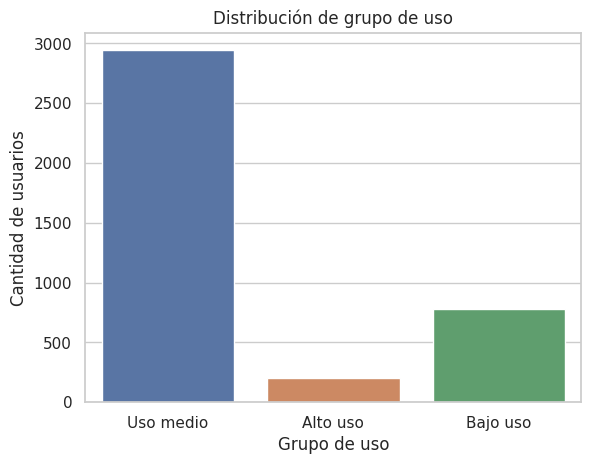

In [47]:
# Visualización de los segmentos por uso

sn.countplot(
    data=user_profile_clean,
    x= 'grupo_uso',
)
plt.title('Distribución de grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

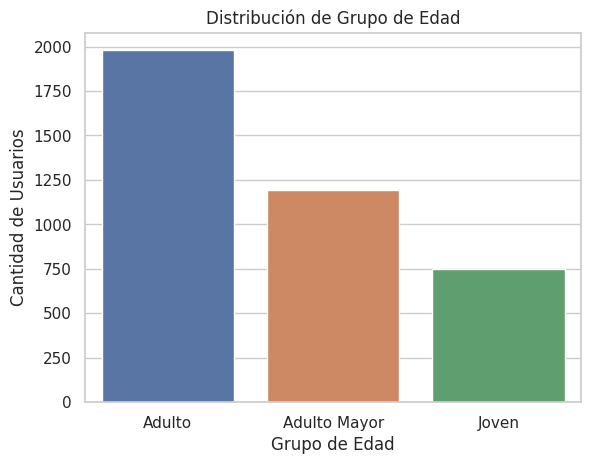

In [48]:
# Visualización de los segmentos por edad

sn.countplot(
    data=user_profile_clean,
    x='grupo_edad',
)
plt.title('Distribución de Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna city presenta celdas vacías que representan casi el 15% de los datos.
- La columna reg_date contiene fechas imposibles y con formato incorrecto; se identificaron registros del año 2026, cuando el análisis corresponde a 2024.
- La columna usd_monthly_pay tenía un formato incorrecto: al representar el costo mensual de un plan, no debía ser de tipo int, sino de tipo float.


🔍 **Segmentos por Edad**
- Los clientes jóvenes (menos de 30 años) suman aproximadamente 750, una cantidad considerable pero pequeña en comparación con otros grupos.
- Los clientes adultos (entre 30 y 60 años) representan la mayoría, con alrededor de 2000 registros.
- Los adultos mayores (entre 60 y 80 años) se ubican en un rango intermedio, con aproximadamente entre 1000 y 1250 clientes.


📊 **Segmentos por Nivel de Uso**
- El segmento de uso medio es el más grande, con entre 2500 y 3000 usuarios.
- Le siguen los usuarios de bajo uso, con aproximadamente entre 500 y 1000 usuarios.
- Finalmente, los usuarios de alto uso representan alrededor de 200 registros.


➡️ Esto sugiere que La mayoría de los clientes de ConectaTel son adultos de uso medio, seguidos por adultos mayores de bajo uso. Esto no implica que no existan adultos con un uso alto del servicio ni que los jóvenes se limiten únicamente al bajo uso. Sin embargo, se observa una clara predominancia de los adultos con uso medio, lo que los posiciona como el segmento de mayor valor para la compañía.


💡 **Recomendaciones**
- Para conocer el consumo real de los usuarios de ConectaTel, podría añadirse un parámetro de segmentación que mida el consumo de MB por usuario. Esto permitiría identificar nuevos patrones y posicionar mejor a los clientes jóvenes.
- Se recomienda incorporar planes con llamadas y mensajes ilimitados, incentivando a los usuarios a utilizar estos medios de comunicación en lugar de depender únicamente de internet.
- Una recomendación adicional es implementar un programa de recompensas por lealtad, dirigido a clientes que se han mantenido en la compañía a lo largo del tiempo. Por ejemplo, un adulto mayor que se registró siendo joven podría recibir beneficios prioritarios, lo que incentivaría la permanencia de otros usuarios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`